Log Transformation

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [37]:
img = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)
img_float = img.astype(np.float32)
img_float = np.clip(img_float, 0, 255)

In [38]:
c = 255.0 / np.log(1+255)
log_transformed = c * np.log1p(img_float)

In [39]:
log_transformed = c * np.log1p(img_float)
log_transformed = np.clip(log_transformed, 0, 255)
log_transformed = log_transformed.astype(np.uint8)

Text(0.5, 1.0, 'Log Transformed')

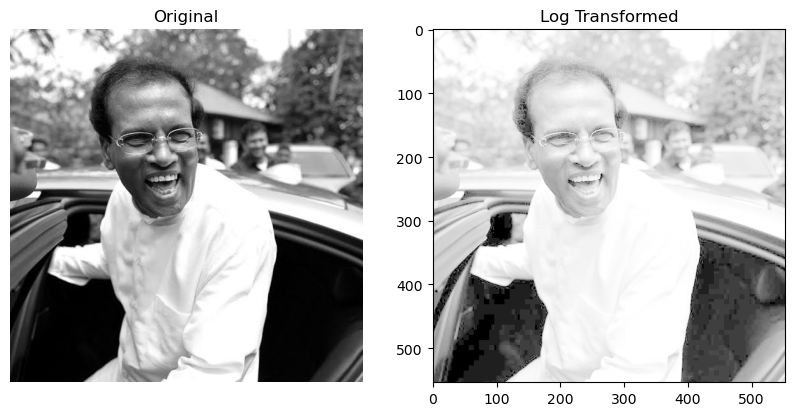

In [40]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_transformed, cmap='gray')
plt.title('Log Transformed')

Log Transformation using OpenCV built in function

In [41]:
img_plus_one = img + 1
img_plus_one = img_plus_one.astype(np.float32)

In [42]:
log_cv2_raw = cv2.log(img_plus_one)
log_transformed_cv2 = c * log_cv2_raw
log_transformed_cv2 = np.clip(log_transformed_cv2, 0, 255)
log_transformed_cv2 = log_transformed_cv2.astype(np.uint8)

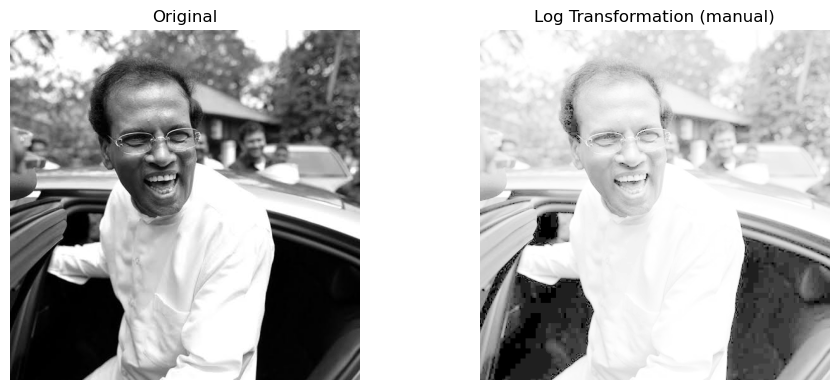

In [43]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_transformed, cmap='gray')
plt.title("Log Transformation (manual)")
plt.axis('off')

plt.tight_layout()
plt.show()

Gamma Transformation

In [44]:
normalized = img / 255.0

In [45]:
gamma_04 = np.power(normalized, 0.4) * 255
gamma_04 = np.clip(gamma_04, 0, 255)
gamma_04 = gamma_04.astype(np.uint8)

In [46]:
gamma_10 = np.power(normalized, 1.0) * 255
gamma_10 = np.clip(gamma_10, 0, 255)
gamma_10 = gamma_10.astype(np.uint8)

In [47]:
gamma_25 = np.power(normalized, 2.5) * 255
gamma_25 = np.clip(gamma_25, 0, 255)
gamma_25 = gamma_25.astype(np.uint8)

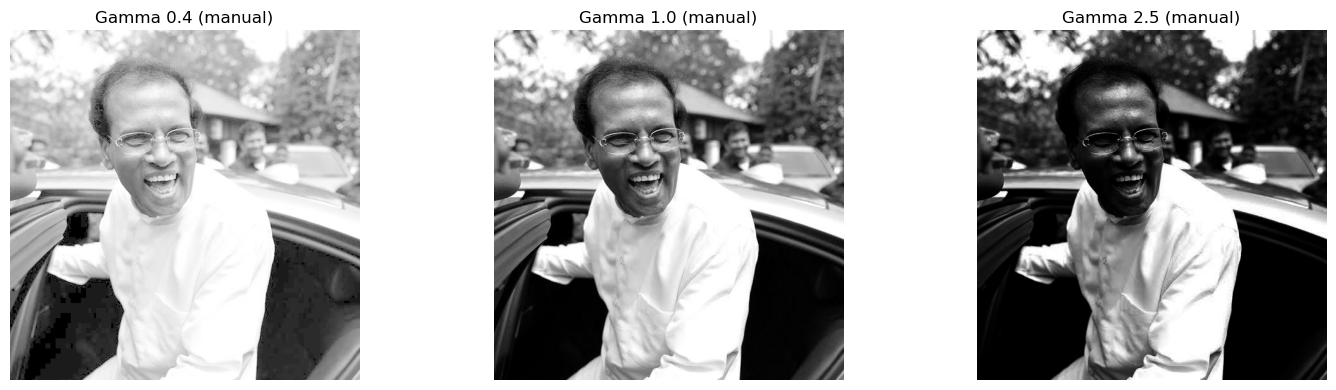

In [48]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.imshow(gamma_04, cmap='gray')
plt.title("Gamma 0.4 (manual)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gamma_10, cmap='gray')
plt.title("Gamma 1.0 (manual)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gamma_25, cmap='gray')
plt.title("Gamma 2.5 (manual)")
plt.axis('off')

plt.tight_layout()
plt.show()

Gamma Transformation using OpenCV built in function

In [49]:
normalized_float32 = normalized.astype(np.float32)

In [50]:
gamma_04_cv2 = cv2.pow(normalized_float32, 0.4) * 255.0
gamma_04_cv2 = np.clip(gamma_04_cv2, 0, 255)
gamma_04_cv2 = gamma_04_cv2.astype(np.uint8)

In [51]:
gamma_25_cv2 = cv2.pow(normalized_float32, 2.5) * 255.0
gamma_25_cv2 = np.clip(gamma_25_cv2, 0, 255)
gamma_25_cv2 = gamma_25_cv2.astype(np.uint8)

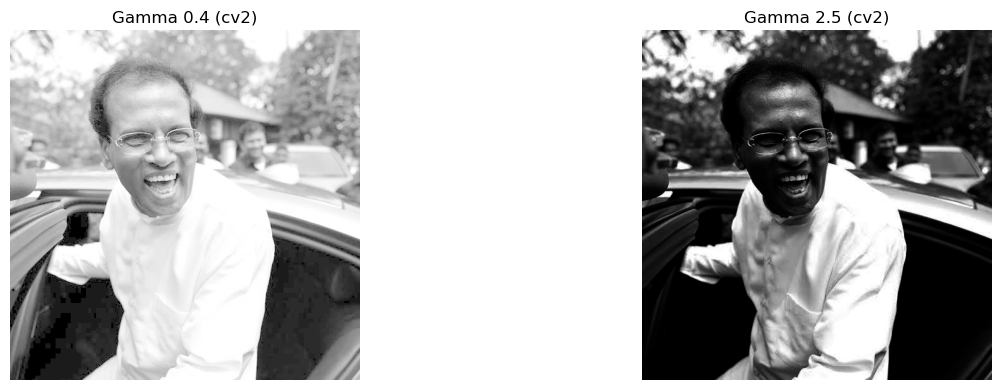

In [52]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.imshow(gamma_04_cv2, cmap='gray')
plt.title("Gamma 0.4 (cv2)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_25_cv2, cmap='gray')
plt.title("Gamma 2.5 (cv2)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Piece-wise Linear Transformation

Using two control points (r1,s1) and (r2,s2)

In [62]:
'''
r = input intensity

r1 -> input intensity where first region ends
r2 -> input intensity where second region ends

s1 -> output value corresponding to r1
s2 -> output value corresponding to r2

0 -> r1  First linear transformation
r1 -> r2  Main stretching region
r2 -> 255  Third linear trransformation

If r1=80, r2=180, s1=30, s2=220,

80---------------------180
30---------------------220

'''

'\nr = input intensity\n\nr1 -> input intensity where first region ends\nr2 -> input intensity where second region ends\n\ns1 -> output value corresponding to r1\ns2 -> output value corresponding to r2\n\n0 -> r1  First linear transformation\nr1 -> r2  Main stretching region\nr2 -> 255  Third linear trransformation\n\nIf r1=80, r2=180, s1=30, s2=220,\n\n80---------------------180\n30---------------------220\n\n'

In [71]:
r1, s1 = 70, 20
r2, s2 = 180, 230

In [72]:
piecewise_result = np.zeros_like(img)

In [73]:
region1 = img < r1
piecewise_result[region1] = (s1/r1) * img[region1]

In [74]:
region2 = (img >= r1) & (img <= r2)
piecewise_result[region2] = ((s2-s1) / (r2-r1)) * (img[region2] - r1) + s1

In [75]:
region3 = img > r2
piecewise_result[region3] = ((255-s2) / (255-r2)) * (img[region3] - r2) + s2

In [ ]:
piecewise_result = np.clip(piecewise_result, 0, 255)
piecewise_result = piecewise_result.astype(np.uint8)

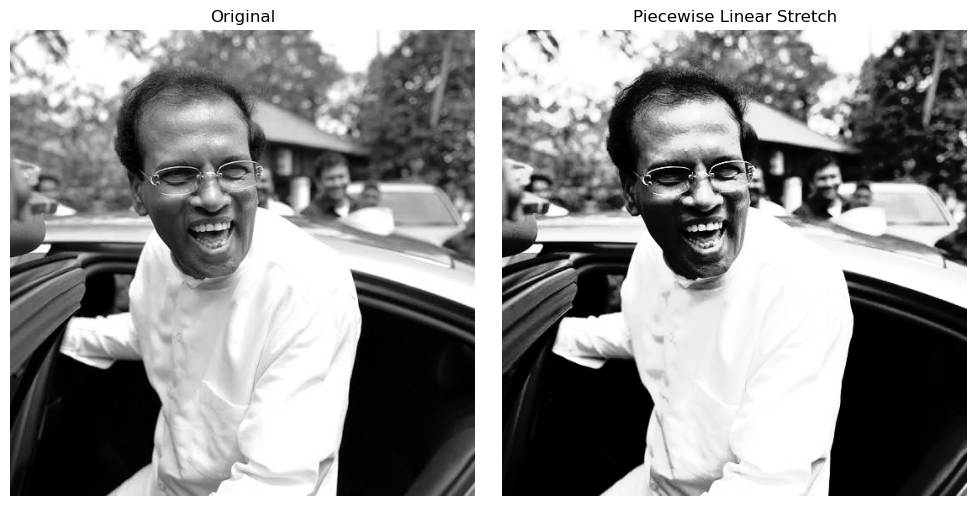

In [78]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(piecewise_result, cmap='gray')
plt.title("Piecewise Linear Stretch")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
'''
apply log transformation to image,display original and log transformed image side by side in same figure area

apply gamma transform with gamma value of own choosing, betwen 0.1 and 0.5.
apply second gamma transform with gamma value of own choosing, betwen 2.0 and 4.0.
same area, display origibal and both gamma transformed result side by side

apply piecewise linear transformation to image using control points of own choosing
apply second piecewise linear transformation to image using different set of control points
same figure area, display original image and both piecewise-transformed result side by side
'''